In [ ]:
import numpy as np
import math
import time
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#step 1 set up parameter
fs = 1000
N = 1024
sigma = 0.5

In [ ]:
n = np.arange(0,N,1)
x1 = np.sin((2*math.pi*100*n)/fs)
x2 = np.sin((2*math.pi*110*n)/fs)
x3 = 0.01 * np.sin((2*math.pi*300*n)/fs)
rng = np.random.default_rng(seed=42)   # seed ไว้เพื่อ reproducibility
v = rng.normal(0, sigma, N)            # scale=σ ไม่ใช่ σ²


x = x1 + x2 + x3 + v

In [ ]:
x

array([0.15235854, 0.71472775, 2.30269151, ..., 1.68509624, 1.63184657,
       1.06586468])

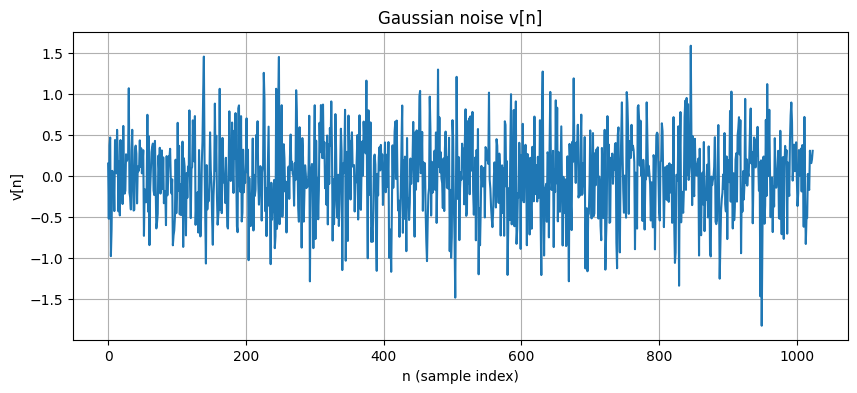

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(n, v)
plt.xlabel("n (sample index)")
plt.ylabel("v[n]")
plt.title("Gaussian noise v[n]")
plt.grid(True)
plt.show()

In [ ]:
def generate_signal(N, fs=1000, sigma=0.5, seed=42):
    n = np.arange(N)
    x1 = np.sin(2 * np.pi * 100 * n / fs)
    x2 = np.sin(2 * np.pi * 110 * n / fs)
    x3 = 0.01 * np.sin(2 * np.pi * 300 * n / fs)
    rng = np.random.default_rng(seed=seed)
    v = rng.normal(0, sigma, N)
    x = x1 + x2 + x3 + v
    return n, x, v

# Periodogram

In [ ]:
def hann_window(L):
    'สร้าง Hann window ความยาว L จุด (เขียนสูตรเอง)'
    if L == 1:
        return np.ones(1)
    k = np.arange(L)
    return 0.5 - 0.5 * np.cos(2 * np.pi * k / (L - 1))

def to_db(P, floor=1e-12):
    'แปลงค่า PSD (linear) เป็น dB อย่างปลอดภัย (กัน log(0) หรือ log(ค่าติดลบ))'
    return 10 * np.log10(np.maximum(P, floor))

In [ ]:
#Periodogram
X = np.fft.fft(x)
X

array([-9.83228495 +0.j        ,  9.57101131 -7.22499603j,
        2.46078928+11.75841115j, ..., 12.58489805 +1.24791682j,
        2.46078928-11.75841115j,  9.57101131 +7.22499603j])

In [ ]:

Pxxk = (1/N)*(abs(X)**2)
Pxxk

array([0.09440803, 0.1404344 , 0.14093332, ..., 0.15618843, 0.14093332,
       0.1404344 ])

In [ ]:
print(Pxxk[:5])
print(np.min(Pxxk))   # ควร >= 0 เสมอ

[0.09440803 0.1404344  0.14093332 0.15618843 0.44756378]
0.0005643873741816741


In [ ]:

k = np.arange(0,N,1)
Fk = k*(fs/N)
Fk

array([0.00000000e+00, 9.76562500e-01, 1.95312500e+00, ...,
       9.97070312e+02, 9.98046875e+02, 9.99023438e+02])

In [ ]:
print(Fk[:5])
print(Fk[-5:])

[0.        0.9765625 1.953125  2.9296875 3.90625  ]
[995.1171875 996.09375   997.0703125 998.046875  999.0234375]


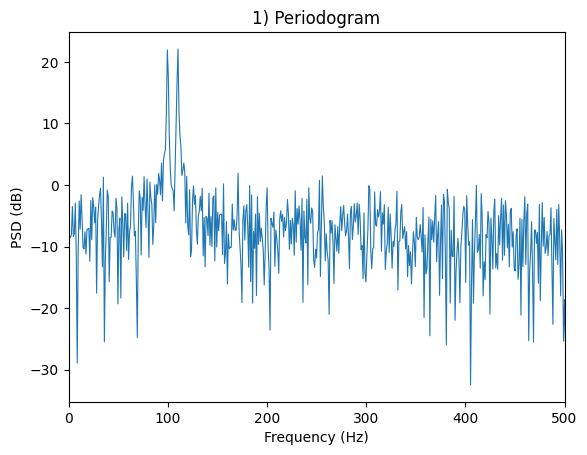

In [ ]:
def periodogram(x, fs):
    N = len(x)
    X = np.fft.fft(x)
    Pxx = (1.0 / N) * np.abs(X) ** 2
    k = np.arange(0,N,1)
    freq = k * fs / N
    return freq, Pxx

f_per, P_per = periodogram(x, fs)

plt.figure()
plt.plot(f_per, to_db(P_per), linewidth=0.8)
plt.xlim(0, fs / 2)
plt.title("1) Periodogram")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.show()

# Modified Periodogram

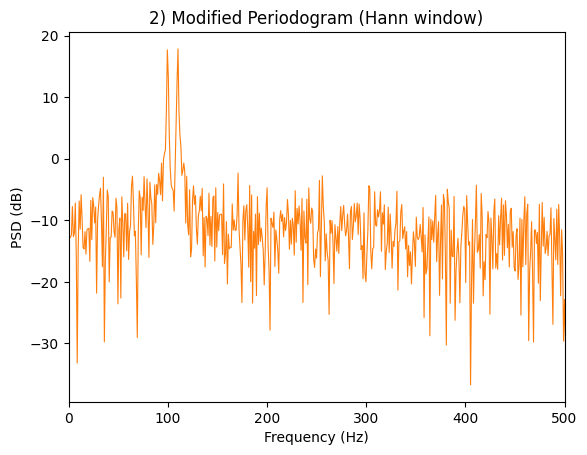

In [ ]:
def modified_periodogram(x, fs):
    N = len(x)
    w = hann_window(N)
    U = np.sum(w ** 2)/N
    Xw = np.fft.fft(x * w)
    Pxx = (1.0 / N*U) * np.abs(X)**2
    freq = np.arange(N) * fs / N
    return freq, Pxx

f_mod, P_mod = modified_periodogram(x, fs)

plt.figure()
plt.plot(f_mod, to_db(P_mod), linewidth=0.8, color="tab:orange")
plt.xlim(0, fs / 2)
plt.title("2) Modified Periodogram (Hann window)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.show()

# Bartlett's Method

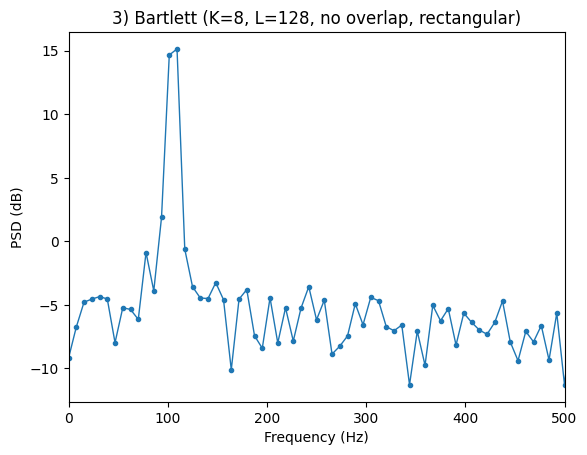

In [ ]:
def bartlett_psd(x, fs, K=8, L=128):
    Pxx_sum = np.zeros(L)
    for i in range(K):
        seg = x[i * L:(i + 1) * L]
        Xi = np.fft.fft(seg)
        Pxx_sum += (1.0 / L) * np.abs(Xi) ** 2
    Pxx = Pxx_sum / K
    freq = np.arange(L) * fs / L
    return freq, Pxx

f_bart, P_bart = bartlett_psd(x, fs, K=8, L=128)

plt.figure()
plt.plot(f_bart, to_db(P_bart), marker="o", markersize=3, linewidth=1)
plt.xlim(0, fs / 2)
plt.title("3) Bartlett (K=8, L=128, no overlap, rectangular)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.show()

# (Welch's method)

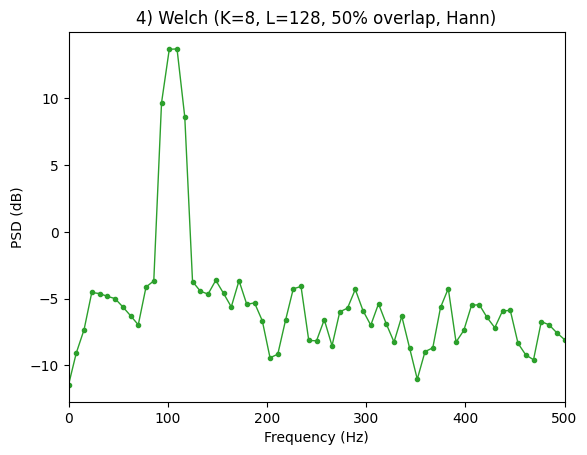

In [ ]:
def welch_psd(x, fs, K=8, L=128, overlap=0.5):
    D = int(L * (1 - overlap))
    w = hann_window(L)
    U = np.sum(w ** 2) / L
    Pxx_sum = np.zeros(L)
    for i in range(K):
        start = i * D
        seg = x[start:start + L] * w
        Xi = np.fft.fft(seg)
        Pxx_sum += (1.0 / (L * U)) * np.abs(Xi) ** 2
    Pxx = Pxx_sum / K
    freq = np.arange(L) * fs / L
    return freq, Pxx

f_welch, P_welch = welch_psd(x, fs, K=8, L=128, overlap=0.5)

plt.figure()
plt.plot(f_welch, to_db(P_welch), marker="o", markersize=3, linewidth=1, color="tab:green")
plt.xlim(0, fs / 2)
plt.title("4) Welch (K=8, L=128, 50% overlap, Hann)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.show()

# Correlogram (Blackman–Tukey)

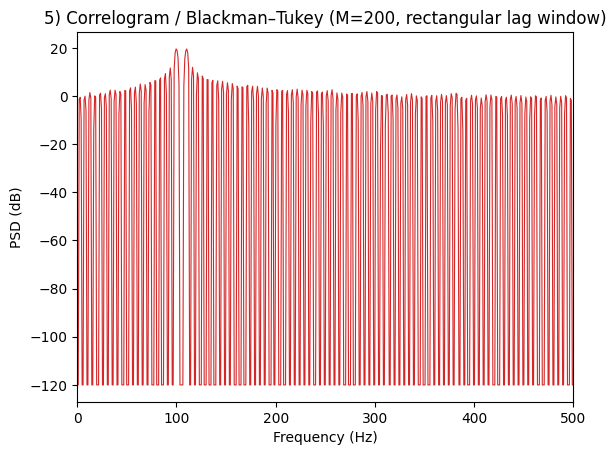

In [ ]:
def biased_autocorr(x, maxlag):
    N = len(x)
    r = np.zeros(maxlag + 1)
    for m in range(maxlag + 1):
        r[m] = np.dot(x[:N - m], x[m:]) / N
    return r

def correlogram_psd(x, fs, M=200, Nfft=None):
    N = len(x)
    if Nfft is None:
        Nfft = N
    r_pos = biased_autocorr(x, M - 1)
    r_full = np.zeros(Nfft)
    r_full[0] = r_pos[0]
    for m in range(1, M):
        r_full[m % Nfft] = r_pos[m]
        r_full[(-m) % Nfft] = r_pos[m]
    Pxx = np.real(np.fft.fft(r_full))
    freq = np.arange(Nfft) * fs / Nfft
    return freq, Pxx

f_corr, P_corr = correlogram_psd(x, fs, M=200, Nfft=N)


plt.figure()
plt.plot(f_corr, to_db(P_corr), linewidth=0.8, color="tab:red")
plt.xlim(0, fs / 2)
plt.title("5) Correlogram / Blackman\u2013Tukey (M=200, rectangular lag window)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.show()

# 1.3 Time and performance

In [ ]:
def time_all_methods(N, fs=1000, sigma=0.5, seed=42, reps=20):
    _, xN, _ = generate_signal(N, fs, sigma, seed)
    funcs = {
        "Periodogram": lambda: periodogram(xN, fs),
        "Modified Periodogram": lambda: modified_periodogram(xN, fs),
        "Bartlett": lambda: bartlett_psd(xN, fs, K=8, L=128),
        "Welch": lambda: welch_psd(xN, fs, K=8, L=128, overlap=0.5),
        "Correlogram": lambda: correlogram_psd(xN, fs, M=200, Nfft=N),
    }
    timings = {}
    for name, func in funcs.items():
        func()  # warm-up (กัน overhead รอบแรก เช่น cache/allocation)
        t0 = time.perf_counter()
        for _ in range(reps):
            func()
        t1 = time.perf_counter()
        timings[name] = (t1 - t0) / reps
    return timings

Ns = [2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16]
timing_results = {N_: time_all_methods(N_) for N_ in Ns}

df_time = pd.DataFrame(timing_results).T
df_time.index.name = "N"
df_time_ms = df_time * 1000   # แปลงเป็นมิลลิวินาทีให้อ่านง่าย
df_time_ms.columns = [c + " (ms)" for c in df_time_ms.columns]
df_time_ms

,Periodogram (ms),Modified Periodogram (ms),Bartlett (ms),Welch (ms),Correlogram (ms)
N,,,,,
1024,0.104664,0.162125,0.170119,0.199493,0.546816
4096,0.129384,0.307794,0.174261,0.206565,0.752826
16384,0.528303,0.852630,0.161910,0.196048,2.331982
65536,3.221361,5.082417,0.209325,0.244297,6.889841


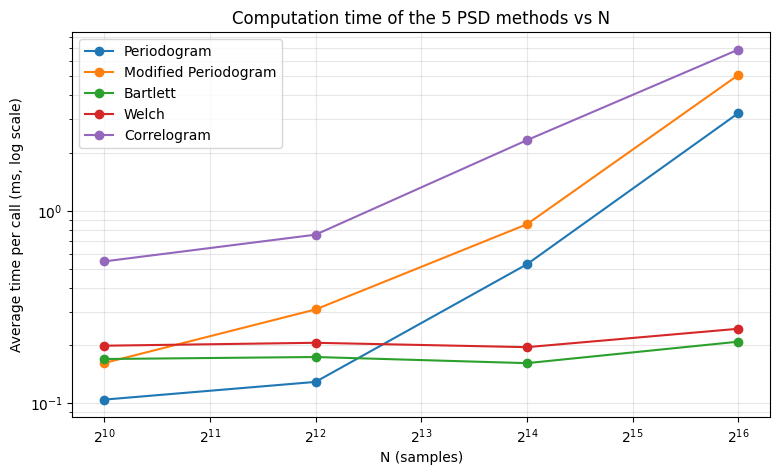

In [ ]:
plt.figure(figsize=(9, 5))
for col in df_time.columns:
    plt.plot(Ns, df_time[col] * 1000, marker="o", label=col)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("N (samples)")
plt.ylabel("Average time per call (ms, log scale)")
plt.title("Computation time of the 5 PSD methods vs N")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()